# 🤖 Notebook 4 — Complaint Routing Model (Vectorization & Classification)

**Project:** AI-Driven Citizen Grievance Analysis

**Input:** data/processed/grievance_processed.csv ← from Notebook 2

**Output:** Trained models saved to `models/` folder

### What this notebook does:
- Data Consolidation: Maps 17+ granular complaint types into 3-5 core government departments to mitigate class imbalance.
- Label Encoding: Converts categorical department names into numerical labels for algorithmic processing.
- TF-IDF Vectorization: Transforms cleaned text into numerical feature matrices using unigrams and bigrams.
- Supervised Learning: Trains and compares Logistic Regression (baseline) and Random Forest (ensemble) models.
- Robust Evaluation: Uses Stratified 3-Fold Cross-Validation to ensure the models generalize well to unseen data.
- Class Balancing: Implements class_weight='balanced' to ensure minority departments (like Social Services) are not ignored by the model.

---

## Import Libraries

In [38]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

## Load Processed Data


In [39]:
# Import the refined dataset
INPUT_FILE = '../data/processed/grievance_processed.csv'
MODEL_DIR = '../models/'
df = pd.read_csv(INPUT_FILE)

# Basic sanity check
print(f'[INFO] Loaded {len(df):,} rows from {INPUT_FILE}')
print("Data Shape:", df.shape)
print(df[['clean_text', 'Complaint Type']].head())

# Drop any rows where text processing failed or department is missing
df = df.dropna(subset=['clean_text', 'Complaint Type'])

[INFO] Loaded 12,387 rows from ../data/processed/grievance_processed.csv
Data Shape: (12387, 20)
                                          clean_text           Complaint Type
0  noise street sidewalk loud music party upon re...  Noise - Street/Sidewalk
1                            blocked driveway access         Blocked Driveway
2      blocked driveway access upon responsible gone         Blocked Driveway
3  illegal parking commercial overnight parking took          Illegal Parking
4  illegal parking blocked sidewalk upon responsi...          Illegal Parking


## Target Variable Analysis & Log-Scale Visualization
- Inspect the distribution of `Complaint Type`. 
- Using a **logarithmic scale** to visualize "minority classes" (like Graffiti or Disorderly Youth)

Complaint Type value counts:
Complaint Type
Illegal Parking              3809
Blocked Driveway             3620
Noise - Commercial           1439
Noise - Street/Sidewalk      1398
Derelict Vehicle              777
Noise - Vehicle               442
Animal Abuse                  262
Homeless Encampment           154
Vending                       146
Traffic                       115
Posting Advertisement          65
Noise - Park                   53
Drinking                       45
Noise - House of Worship       20
Panhandling                    17
Bike/Roller/Skate Chronic       9
Urinating in Public             9
Graffiti                        3
Disorderly Youth                2
Ferry Complaint                 2
Name: count, dtype: int64


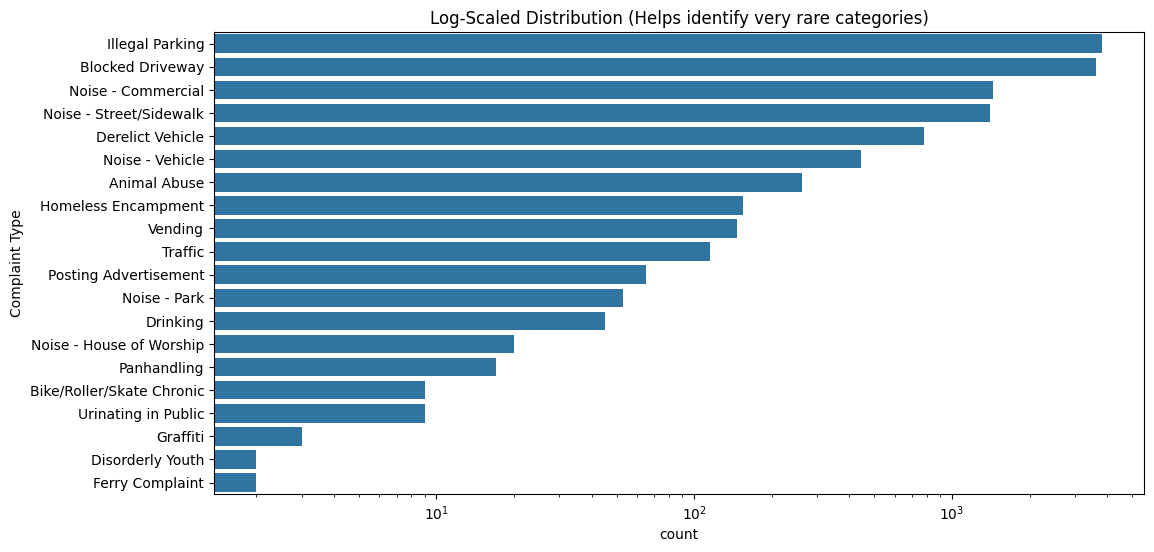

In [40]:
print('Complaint Type value counts:')
print(df['Complaint Type'].value_counts())

# Plotting with a Log Scale to see minority classes
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Complaint Type', order=df['Complaint Type'].value_counts().index)
plt.xscale('log') # This makes the small counts visible
plt.title('Log-Scaled Distribution (Helps identify very rare categories)')
plt.show()

## Hierarchical Label Mapping (Strategic Aggregation)
- To solve the "Long Tail" problem where rare categories have too few samples to train on, we implement **Class Aggregation**. 
- By mapping specific complaints into broad "Super-Departments," we increase data density per category, which significantly improves the F1-Score and model stability.

In [41]:
routing_map = {
    # --- TRANSPORT & STREETS ---
    'Illegal Parking': 'Transport',
    'Blocked Driveway': 'Transport',
    'Derelict Vehicle': 'Transport',
    'Traffic': 'Transport',
    'Vending': 'Transport',
    'Posting Advertisement': 'Transport',
    'Bike/Roller/Skate Chronic': 'Transport',
    
    # --- ENVIRONMENT & NOISE ---
    'Noise - Street/Sidewalk': 'Environment',
    'Noise - Commercial': 'Environment',
    'Noise - Vehicle': 'Environment',
    'Noise - Park': 'Environment',
    'Graffiti': 'Environment', # Grouped here as a Quality of Life/Aesthetic issue
    
    # --- SOCIAL & HEALTH SERVICES ---
    'Animal Abuse': 'Social & Health Services',
    'Homeless Encampment': 'Social & Health Services',
    'Drinking': 'Social & Health Services',
    'Panhandling': 'Social & Health Services',
    'Disorderly Youth': 'Social & Health Services'
}

# Apply the map and drop anything that doesn't fit
df['Department'] = df['Complaint Type'].map(routing_map)
df = df.dropna(subset=['Department']).reset_index(drop=True)

print('[INFO] New Department Distribution:')
print(df['Department'].value_counts())

[INFO] New Department Distribution:
Department
Transport                   8541
Environment                 3335
Social & Health Services     480
Name: count, dtype: int64


## Label Encoding
Since machine learning algorithms operate on mathematical equations, they cannot process text strings directly. We use `LabelEncoder` to translate our "Department" names into integers (0, 1, 2, etc.). This acts as a bridge between human-readable categories and the model's numerical requirements.

In [42]:
le = LabelEncoder()
y = le.fit_transform(df['Department'])
X = df['clean_text'].astype(str)
joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print('Saved label encoder in', MODEL_DIR + 'label_encoder.pkl')

Saved label encoder in ../models/label_encoder.pkl


## Stratified Train/Test Split

In [43]:
# Define features and target
X_raw = df['clean_text']
y_raw = df['Complaint Type']

# Vectorizer should be fit on training data ONLY.
# Using stratified split to maintain class balance.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set Size: {X_train_raw.shape[0]}")
print(f"Testing Set Size: {X_test_raw.shape[0]}")

Training Set Size: 9884
Testing Set Size: 2472


## Standardized Pipeline Components

In [44]:
# Define consistent parameters for fair comparison
vectorizer_params = {
    'ngram_range': (1, 2),
    'max_features': 5000,
    'min_df': 3,
    'stop_words': 'english'
}

# Define Model 1: Random Forest
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(**vectorizer_params)),
    ('clf', RandomForestClassifier(n_estimators=250, max_depth=25, class_weight='balanced', random_state=42, n_jobs=-1))
])

# Define Model 2: Logistic Regression
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**vectorizer_params)),
    ('clf', LogisticRegression(solver='saga', max_iter=2000, class_weight='balanced', random_state=42))
])

## Unified Evaluation Logic: Apply CV to BOTH Models

In [45]:
# Use standard cross-validation object and metrics
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

# --- Cross-Validation Part 1: Logistic Regression -------
cv_results_lr = cross_validate(pipeline_lr, X_train_raw, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('Logistic Regression CV Results:')
for m in scoring:
    print(m, f'{cv_results_lr["test_"+m].mean():.4f} +/- {cv_results_lr["test_"+m].std():.4f}')
print('-' * 20)

# --- Cross-Validation Part 2: Random Forest --------
cv_results_rf = cross_validate(pipeline_rf, X_train_raw, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('Random Forest CV Results:')
for m in scoring:
    print(m, f'{cv_results_rf["test_"+m].mean():.4f} +/- {cv_results_rf["test_"+m].std():.4f}')
print('-' * 20)

Logistic Regression CV Results:
accuracy 0.9994 +/- 0.0007
f1_macro 0.9980 +/- 0.0019
precision_macro 0.9973 +/- 0.0037
recall_macro 0.9987 +/- 0.0011
--------------------
Random Forest CV Results:
accuracy 0.9995 +/- 0.0005
f1_macro 0.9981 +/- 0.0019
precision_macro 0.9974 +/- 0.0036
recall_macro 0.9988 +/- 0.0011
--------------------
